In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import pandas as pd
import numpy as np
import os

from aquacrop_slovenia import config

In [37]:
temp = pd.read_csv(config.RAW_WEATHER_DIR / "station_8_temperature.csv", sep=";")
precip = pd.read_csv(config.RAW_WEATHER_DIR / "station_8_precipitation.csv", sep=";")
et = pd.read_csv(config.RAW_WEATHER_DIR / "station_8_evapotranspiration.csv", sep=";")

In [38]:
temp["datum"] = pd.to_datetime(temp.datum, format="%m.%d.%Y")
precip["datum"] = pd.to_datetime(precip.datum, format="%m.%d.%Y")
et["datum"] = pd.to_datetime(et.datum, format="%m.%d.%Y")

C:\Users\rokku\AppData\Local\Temp\ipykernel_9128\3531301229.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  temp["datum"] = pd.to_datetime(temp.datum, format="%m.%d.%Y")
C:\Users\rokku\AppData\Local\Temp\ipykernel_9128\3531301229.py:2: F

In [39]:
temp

,postaja,datum,tpov,tmin,tmax
0,8,1993-01-01,-7.0,-12.0,-1.0
1,8,1993-01-02,-8.6,-14.5,-4.2
2,8,1993-01-03,-6.1,-9.2,-3.1
3,8,1993-01-04,-7.2,-9.7,-3.3
4,8,1993-01-05,-8.7,-13.2,-2.5
...,...,...,...,...,...
11317,8,2023-12-27,5.1,-2.1,10.9
11318,8,2023-12-28,7.6,1.7,11.0
11319,8,2023-12-29,5.9,-1.7,11.5
11320,8,2023-12-30,4.0,-1.5,11.3


In [40]:
temp.describe()

,postaja,datum,tpov,tmin,tmax
count,11322.0,11322,11322.000000,11322.000000,11322.000000
mean,8.0,2008-07-01 12:00:00,9.556147,4.265775,15.616207
min,8.0,1993-01-01 00:00:00,-17.100000,-23.700000,-9.100000
25%,8.0,2000-10-01 06:00:00,2.700000,-1.600000,8.100000
50%,8.0,2008-07-01 12:00:00,10.000000,4.700000,16.100000
75%,8.0,2016-03-31 18:00:00,16.500000,10.700000,23.300000
max,8.0,2023-12-31 00:00:00,28.300000,20.800000,38.100000
std,0.0,NaN,8.273927,7.625235,9.417377


In [41]:
precip

,postaja,datum,pad
0,8,1993-01-01,0.0
1,8,1993-01-02,0.0
2,8,1993-01-03,0.0
3,8,1993-01-04,0.0
4,8,1993-01-05,0.0
...,...,...,...
11317,8,2023-12-27,0.0
11318,8,2023-12-28,0.0
11319,8,2023-12-29,0.0
11320,8,2023-12-30,0.0


In [42]:
precip.describe()

,postaja,datum,pad
count,11322.0,11322,11322.000000
mean,8.0,2008-07-01 12:00:00,3.660731
min,8.0,1993-01-01 00:00:00,0.000000
25%,8.0,2000-10-01 06:00:00,0.000000
50%,8.0,2008-07-01 12:00:00,0.000000
75%,8.0,2016-03-31 18:00:00,1.900000
max,8.0,2023-12-31 00:00:00,227.100000
std,0.0,NaN,9.488262


In [43]:
et

,postaja,datum,etp
0,8,1993-01-01,0.3
1,8,1993-01-02,0.6
2,8,1993-01-03,0.7
3,8,1993-01-04,0.3
4,8,1993-01-05,0.2
...,...,...,...
11104,8,2023-12-27,0.2
11105,8,2023-12-28,0.7
11106,8,2023-12-29,0.4
11107,8,2023-12-30,0.5


In [44]:
et.describe()

,postaja,datum,etp
count,11109.0,11109,11062.000000
mean,8.0,2008-04-30 21:58:24.725897984,2.015142
min,8.0,1993-01-01 00:00:00,0.000000
25%,8.0,2000-08-09 00:00:00,0.500000
50%,8.0,2008-03-17 00:00:00,1.500000
75%,8.0,2015-10-24 00:00:00,3.300000
max,8.0,2023-12-31 00:00:00,7.200000
std,0.0,NaN,1.650789


In [45]:
meteo_data = pd.merge(pd.merge(temp, precip, on="datum", how="outer"), et, on="datum", how="outer")
meteo_data.drop(["postaja_x", "postaja_y", "postaja"], axis=1, inplace=True)

In [46]:
meteo_data

,datum,tpov,tmin,tmax,pad,etp
0,1993-01-01,-7.0,-12.0,-1.0,0.0,0.3
1,1993-01-02,-8.6,-14.5,-4.2,0.0,0.6
2,1993-01-03,-6.1,-9.2,-3.1,0.0,0.7
3,1993-01-04,-7.2,-9.7,-3.3,0.0,0.3
4,1993-01-05,-8.7,-13.2,-2.5,0.0,0.2
...,...,...,...,...,...,...
11317,2023-12-27,5.1,-2.1,10.9,0.0,0.2
11318,2023-12-28,7.6,1.7,11.0,0.0,0.7
11319,2023-12-29,5.9,-1.7,11.5,0.0,0.4
11320,2023-12-30,4.0,-1.5,11.3,0.0,0.5


In [47]:
meteo_data.describe()

,datum,tpov,tmin,tmax,pad,etp
count,11322,11322.000000,11322.000000,11322.000000,11322.000000,11062.000000
mean,2008-07-01 12:00:00,9.556147,4.265775,15.616207,3.660731,2.015142
min,1993-01-01 00:00:00,-17.100000,-23.700000,-9.100000,0.000000,0.000000
25%,2000-10-01 06:00:00,2.700000,-1.600000,8.100000,0.000000,0.500000
50%,2008-07-01 12:00:00,10.000000,4.700000,16.100000,0.000000,1.500000
75%,2016-03-31 18:00:00,16.500000,10.700000,23.300000,1.900000,3.300000
max,2023-12-31 00:00:00,28.300000,20.800000,38.100000,227.100000,7.200000
std,NaN,8.273927,7.625235,9.417377,9.488262,1.650789


## Visualize data

<Axes: xlabel='datum'>

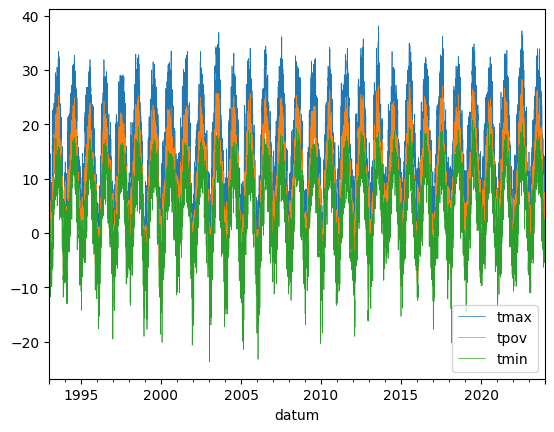

In [48]:
meteo_data.plot(x="datum", y=["tmax", "tpov", "tmin"], linewidth=0.5)

<Axes: xlabel='datum'>

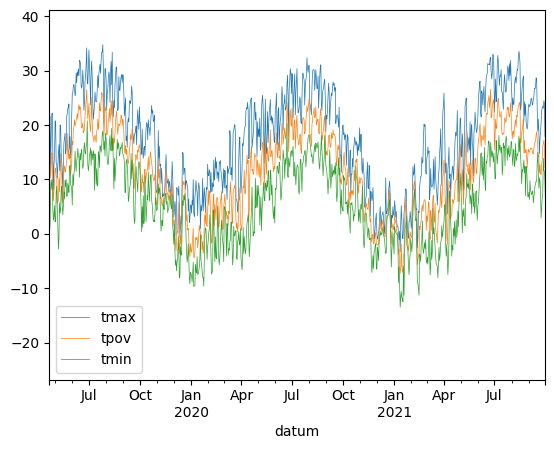

In [49]:
meteo_data.plot(x="datum", y=["tmax", "tpov", "tmin"], linewidth=0.5, xlim=("2019-04-20","2021-09-30"))

<Axes: xlabel='datum'>

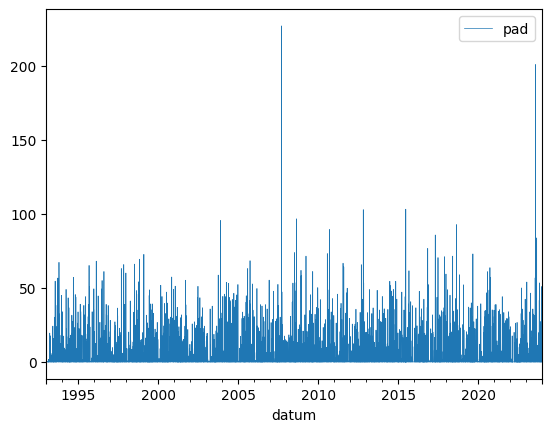

In [50]:
meteo_data.plot(x="datum", y=["pad"], linewidth=0.5)

<Axes: xlabel='datum'>

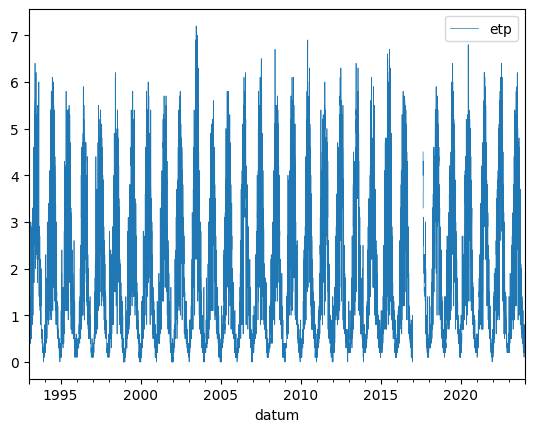

In [51]:
meteo_data.plot(x="datum", y=["etp"], linewidth=0.5)

<Axes: xlabel='datum'>

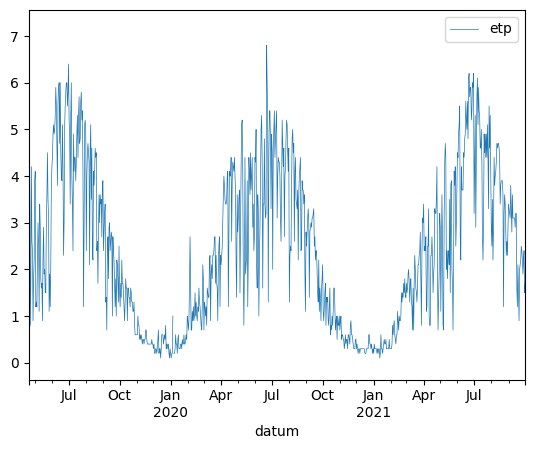

In [52]:
meteo_data.plot(x="datum", y=["etp"], linewidth=0.5, xlim=("2019-04-20","2021-09-30"))

## Weather statistics

In [53]:
climate_data = meteo_data.copy()
climate_data.loc[:, "Year"] = climate_data["datum"].dt.year
climate_data.loc[:, "Month"] = climate_data["datum"].dt.month
climate_data.loc[:, "Day"] = climate_data["datum"].dt.day
yearly_mean = climate_data.groupby('Year').mean()
yearly_sum = climate_data.groupby('Year').sum(numeric_only=True)
daily_mean = climate_data.groupby(['Month', 'Day']).mean()
daily_sum = climate_data.groupby("Year").cumsum(numeric_only=True)
monthly_mean = climate_data.groupby(['Month']).mean()
## Monthly ETP climatology
_etp = meteo_data[meteo_data["datum"].dt.year.between(1993, 2020) & (meteo_data["datum"].dt.year != 2017)]
monthly_etp = (
    _etp.groupby([_etp["datum"].dt.year, _etp["datum"].dt.month])["etp"]
    .sum()
    .groupby(level=1)
    .mean()
)
monthly_etp.index.name = "Month"

In [54]:
monthly_etp

Month
1      10.874074
2      19.759259
3      45.633333
4      72.344444
5     103.611111
6     121.051852
7     129.588889
8     109.237037
9      63.481481
10     33.718519
11     15.000000
12      8.329630
Name: etp, dtype: float64

In [55]:
monthly_etp.sum()

np.float64(732.6296296296297)

In [56]:
yearly_mean[["tmin", "tpov", "tmax", "pad", "etp"]]

,tmin,tpov,tmax,pad,etp
Year,,,,,
1993,3.412603,8.726849,14.800000,3.235342,2.083836
1994,4.718082,9.856164,15.933425,3.466849,2.041644
1995,3.626575,8.638904,14.603288,3.935068,1.905753
1996,3.401639,7.926503,13.158197,3.933880,1.761749
1997,3.583836,8.675890,14.750959,3.134521,1.986849
1998,3.657260,8.939452,15.283836,3.692603,1.944384
1999,3.976164,8.898082,14.691781,3.809589,1.862466
2000,4.362568,9.957104,16.376776,3.932514,2.043169
2001,3.988493,9.277808,15.248219,3.205205,1.917260


<Axes: xlabel='Year'>

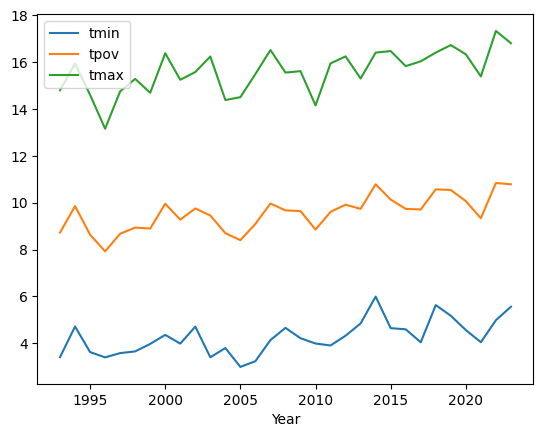

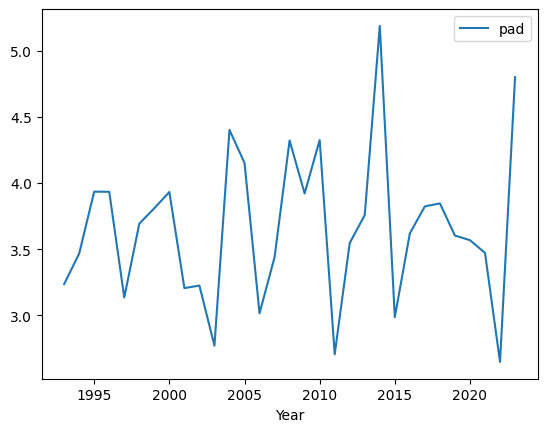

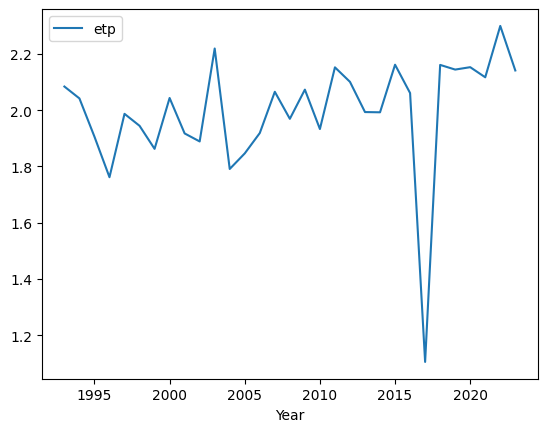

In [57]:
yearly_mean.plot(y=["tmin", "tpov", "tmax"])
yearly_mean.plot(y="pad")
yearly_mean.plot(y="etp")

Yearly sums of precipitation and ET

<Axes: xlabel='Year'>

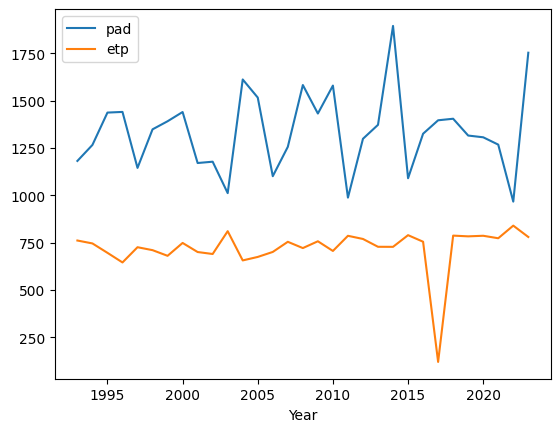

In [58]:
yearly_sum.plot(y=["pad", "etp"])

Climatology (whole period)

<Axes: xlabel='Month,Day'>

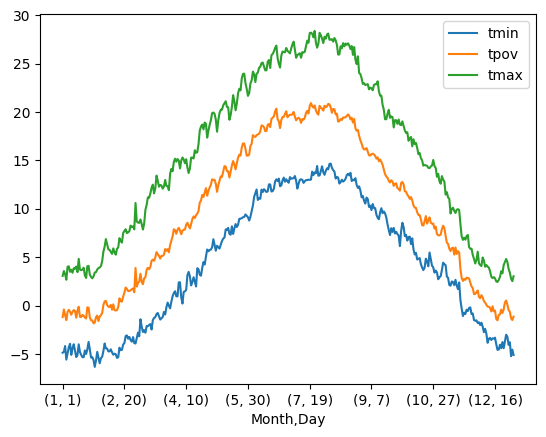

In [59]:
daily_mean.plot(y=["tmin", "tpov", "tmax"])

<Axes: >

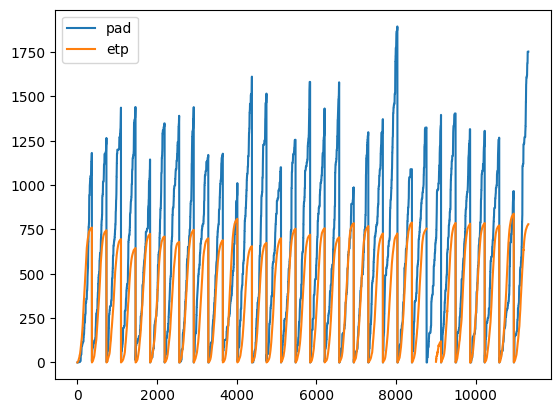

In [60]:
daily_sum.plot(y=["pad", "etp"])

In [61]:
monthly_mean

,datum,tpov,tmin,tmax,pad,etp,Year,Day
Month,,,,,,,,
1,2008-01-16 09:17:25.161290240,-0.989386,-4.931946,3.567742,2.174818,0.353391,2008.0,16.000
2,2008-02-15 00:00:00.000000000,0.524229,-4.347200,6.563086,2.656114,0.724793,2008.0,14.616
3,2008-03-15 14:42:34.838709760,4.578044,-1.342456,11.482102,2.444641,1.505376,2008.0,16.000
4,2008-04-15 02:42:34.838709760,9.427742,2.988602,16.212366,2.962688,2.404556,2008.0,15.500
5,2008-05-15 14:42:34.838709504,14.342456,7.695838,20.984079,3.544745,3.317527,2008.0,16.000
6,2008-06-15 02:42:34.838709504,18.595161,11.923333,25.044301,4.137419,4.102670,2008.0,15.500
7,2008-07-15 14:42:34.838709760,19.905203,13.237669,26.942456,3.988762,4.229247,2008.0,16.000
8,2008-08-15 14:42:34.838709504,19.235276,13.162435,26.430177,4.520708,3.542888,2008.0,16.000
9,2008-09-15 02:42:34.838709504,14.237204,9.082043,20.994731,5.172688,2.151204,2008.0,15.500


<Axes: xlabel='Month'>

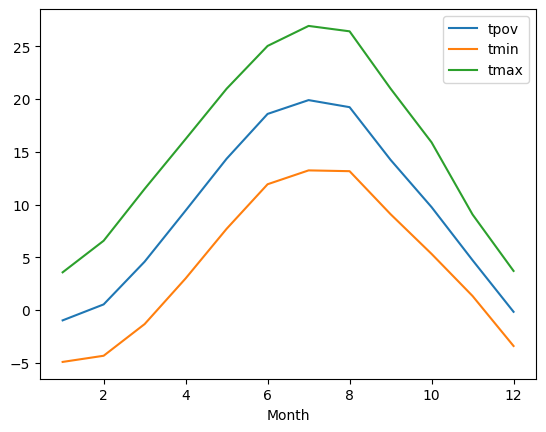

In [62]:
monthly_mean.plot(y=["tpov", "tmin", "tmax"])

<Axes: xlabel='Month'>

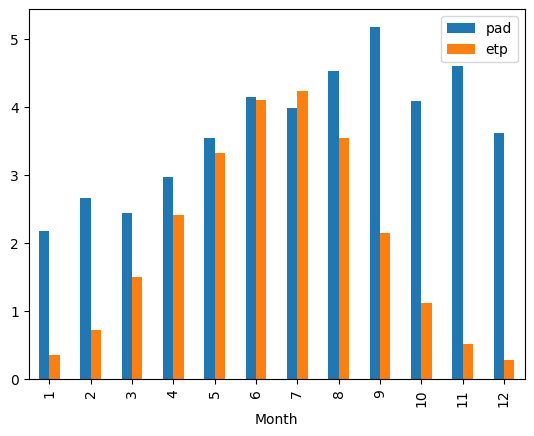

In [63]:
monthly_mean.plot(y=["pad", "etp"], kind="bar")

## Missing data

In [64]:
for variable_name in ["tmin", "tpov", "tmax", "pad", "etp"]:
    print(variable_name)
    print(meteo_data[meteo_data[variable_name].isnull()])

tmin
Empty DataFrame
Columns: [datum, tpov, tmin, tmax, pad, etp]
Index: []
tpov
Empty DataFrame
Columns: [datum, tpov, tmin, tmax, pad, etp]
Index: []
tmax
Empty DataFrame
Columns: [datum, tpov, tmin, tmax, pad, etp]
Index: []
pad
Empty DataFrame
Columns: [datum, tpov, tmin, tmax, pad, etp]
Index: []
etp
           datum  tpov  tmin  tmax  pad  etp
8766  2017-01-01  -5.7 -12.5   4.8  0.0  NaN
8767  2017-01-02  -0.6 -11.3   8.6  0.0  NaN
8768  2017-01-03  -3.0  -7.4   4.0  0.0  NaN
8769  2017-01-04  -3.1 -10.3   4.0  0.0  NaN
8770  2017-01-05  -2.0 -10.0   3.7  0.0  NaN
...          ...   ...   ...   ...  ...  ...
9044  2017-10-06   8.6   4.1  15.5  0.0  NaN
9070  2017-11-01   5.0  -3.2  13.4  0.0  NaN
9286  2018-06-05  17.6  12.5  26.9  0.0  NaN
9866  2020-01-06  -4.2  -9.7   3.9  0.0  NaN
11202 2023-09-03  19.9  12.4  26.1  0.0  NaN

[260 rows x 6 columns]


In [65]:
meteo_data[meteo_data["etp"].isnull()]["datum"].tolist()

[Timestamp('2017-01-01 00:00:00'),
 Timestamp('2017-01-02 00:00:00'),
 Timestamp('2017-01-03 00:00:00'),
 Timestamp('2017-01-04 00:00:00'),
 Timestamp('2017-01-05 00:00:00'),
 Timestamp('2017-01-06 00:00:00'),
 Timestamp('2017-01-07 00:00:00'),
 Timestamp('2017-01-08 00:00:00'),
 Timestamp('2017-01-09 00:00:00'),
 Timestamp('2017-01-10 00:00:00'),
 Timestamp('2017-01-11 00:00:00'),
 Timestamp('2017-01-12 00:00:00'),
 Timestamp('2017-01-13 00:00:00'),
 Timestamp('2017-01-14 00:00:00'),
 Timestamp('2017-01-15 00:00:00'),
 Timestamp('2017-01-16 00:00:00'),
 Timestamp('2017-01-17 00:00:00'),
 Timestamp('2017-01-18 00:00:00'),
 Timestamp('2017-01-19 00:00:00'),
 Timestamp('2017-01-20 00:00:00'),
 Timestamp('2017-01-21 00:00:00'),
 Timestamp('2017-01-22 00:00:00'),
 Timestamp('2017-01-23 00:00:00'),
 Timestamp('2017-01-24 00:00:00'),
 Timestamp('2017-01-25 00:00:00'),
 Timestamp('2017-01-26 00:00:00'),
 Timestamp('2017-01-27 00:00:00'),
 Timestamp('2017-01-28 00:00:00'),
 Timestamp('2017-01-

## Infill missing data

We set all missing ET to 0


In [66]:
meteo_data.loc[meteo_data["etp"].isnull(), "etp"] = 0

## Monthly ETP climatology

In [67]:
_etp = meteo_data[meteo_data["datum"].dt.year.between(1993, 2020) & (meteo_data["datum"].dt.year != 2017)]
monthly_etp = (
    _etp.groupby([_etp["datum"].dt.year, _etp["datum"].dt.month])["etp"]
    .sum()
    .groupby(level=1)
    .mean()
)
monthly_etp.index.name = "Month"
monthly_etp

Month
1      10.874074
2      19.759259
3      45.633333
4      72.344444
5     103.611111
6     121.051852
7     129.588889
8     109.237037
9      63.481481
10     33.718519
11     15.000000
12      8.329630
Name: etp, dtype: float64

## Export infilled data

In [68]:
pd.to_pickle(meteo_data, config.PROCESSED_WEATHER_DIR / "station_8.pkl")